Training on 14600 fights, Testing on 3650 fights...
[0]	validation_0-logloss:0.68746	validation_1-logloss:0.69225
[100]	validation_0-logloss:0.57598	validation_1-logloss:0.65982
[200]	validation_0-logloss:0.54187	validation_1-logloss:0.65901
[224]	validation_0-logloss:0.53499	validation_1-logloss:0.66035

--- Results ---
Accuracy: 0.6101
ROC AUC:  0.6529

Confusion Matrix:
[[1108  717]
 [ 706 1119]]


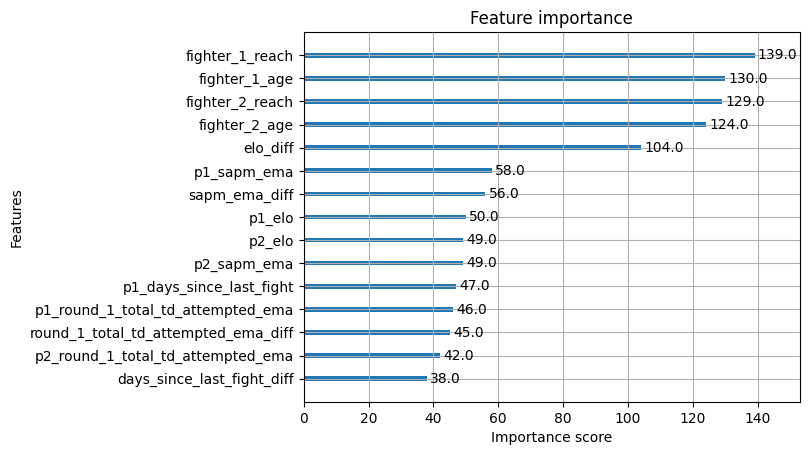

In [2]:
import pandas as pd
import xgboost as xgb
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

# 1. Load Data
# Assuming the data is in a file named 'ufc_data.csv'
df = pd.read_csv('train.csv')

# 2. Preprocessing
# Convert date to datetime
df['event_date'] = pd.to_datetime(df['event_date'])

# Sort by date (CRITICAL for sports betting models)
df = df.sort_values(by='event_date')

# Drop rows where target is missing (if any)
df = df.dropna(subset=['meta_first_fighter_won'])

# Select Features
# We drop non-predictive metadata (names, dates) and the target variable
target = 'meta_first_fighter_won'
meta_cols = ['event_date', 'fighter_1', 'fighter_2', target]
features = [col for col in df.columns if col not in meta_cols]

# 3. Time-Series Split
# Train on first 80% of chronological fights, test on most recent 20%
split_idx = int(len(df) * 0.8)

X = df[features]
y = df[target]

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# 4. The "Best" Robust Baseline Parameters
# These are tuned for high-noise tabular data (like sports) to prevent overfitting
params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'n_estimators': 1000,         # High number, but we use early_stopping
    'learning_rate': 0.05,        # Slower learning for better generalization
    'max_depth': 4,               # Shallower trees reduce overfitting (sports data is noisy)
    'subsample': 0.8,             # Use 80% of rows per tree
    'colsample_bytree': 0.8,      # Use 80% of columns per tree
    'gamma': 0.1,                 # Minimum loss reduction to make a split
    'reg_alpha': 0.1,             # L1 regularization
    'reg_lambda': 1.0,            # L2 regularization
    'scale_pos_weight': 1,        # Change if your dataset is imbalanced (e.g. 10% wins)
    'random_state': 42,
    'tree_method': 'hist',        # Faster training
    'enable_categorical': True    # Useful if you have categorical types properly cast
}

# 5. Training with Early Stopping
model = xgb.XGBClassifier(**params, early_stopping_rounds=50)

print(f"Training on {len(X_train)} fights, Testing on {len(X_test)} fights...")

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=100  # Print progress every 100 rounds
)

# 6. Evaluation
preds = model.predict(X_test)
probs = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, preds)
auc = roc_auc_score(y_test, probs)

print(f"\n--- Results ---")
print(f"Accuracy: {acc:.4f}")
print(f"ROC AUC:  {auc:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, preds))

# 7. Feature Importance (Check what actually matters)
import matplotlib.pyplot as plt
xgb.plot_importance(model, max_num_features=15)
plt.show()